# Parametrized Lattice Packing

Always-phenotype GA with bilevel genome:
- **Primary genome** (xyt): all tree positions, freely optimized by L-BFGS and tree mutations
- **Meta genome** (lattice_params): 10 parameters that periodically overwrite `xyt[:, :n_inner]`

Lattice params: `[t_same, t_horiz, t_vert, theta, anchor_dx, anchor_dy, n_inner, p, shift_dx, shift_dy]`

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'core'))
import kaggle_support as kgs
import pack_io
import pack_parametrized_lattice as ppl
import pandas as pd
import pack_vis_sol
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

best_solutions, _ = pack_io.dataframe_to_solution_list(pd.read_csv(kgs.submission_csv_path))

Detected environment: local


In [5]:
def solve(num_trees: int, seed: int = 42):
    """Run parametrized lattice GA for a given number of trees."""
    runner = ppl.baseline_parametrized_lattice()
    runner.ga.ga_base.N_trees_to_do = num_trees
    runner.diagnostic_plot = True
    runner.seed = seed
    runner.plot_every = 20

    runner.run()

    clear_output(wait=True)
    runner.ga.diagnostic_plots(runner._current_generation, None)
    plt.close('all')

    champ = runner.ga.champions[0].phenotype
    score = float(champ.h[0, 0].get() ** 2 / num_trees)

    best = best_solutions[num_trees - 1]
    best_score = float(best.h[0, 0].get() ** 2 / num_trees)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    pack_vis_sol.pack_vis_sol(champ, ax=ax[0])
    ax[0].set_title(f'Lattice GA, score={score:.6f}')
    pack_vis_sol.pack_vis_sol(best, ax=ax[1])
    ax[1].set_title(f'Best submission, score={best_score:.6f}')
    plt.suptitle(f'N={num_trees}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Show lattice params of best solution
    best_geno = runner.ga.champions[0].genotype
    if hasattr(best_geno, 'lattice_params') and best_geno.lattice_params is not None:
        lp = best_geno.lattice_params[0].get()
        names = ['t_same', 't_horiz', 't_vert', 'theta', 'anchor_dx', 'anchor_dy',
                 'n_inner', 'p', 'shift_dx', 'shift_dy']
        print('Lattice params:')
        for name, val in zip(names, lp):
            print(f'  {name:>12s} = {val:.4f}')
    return runner

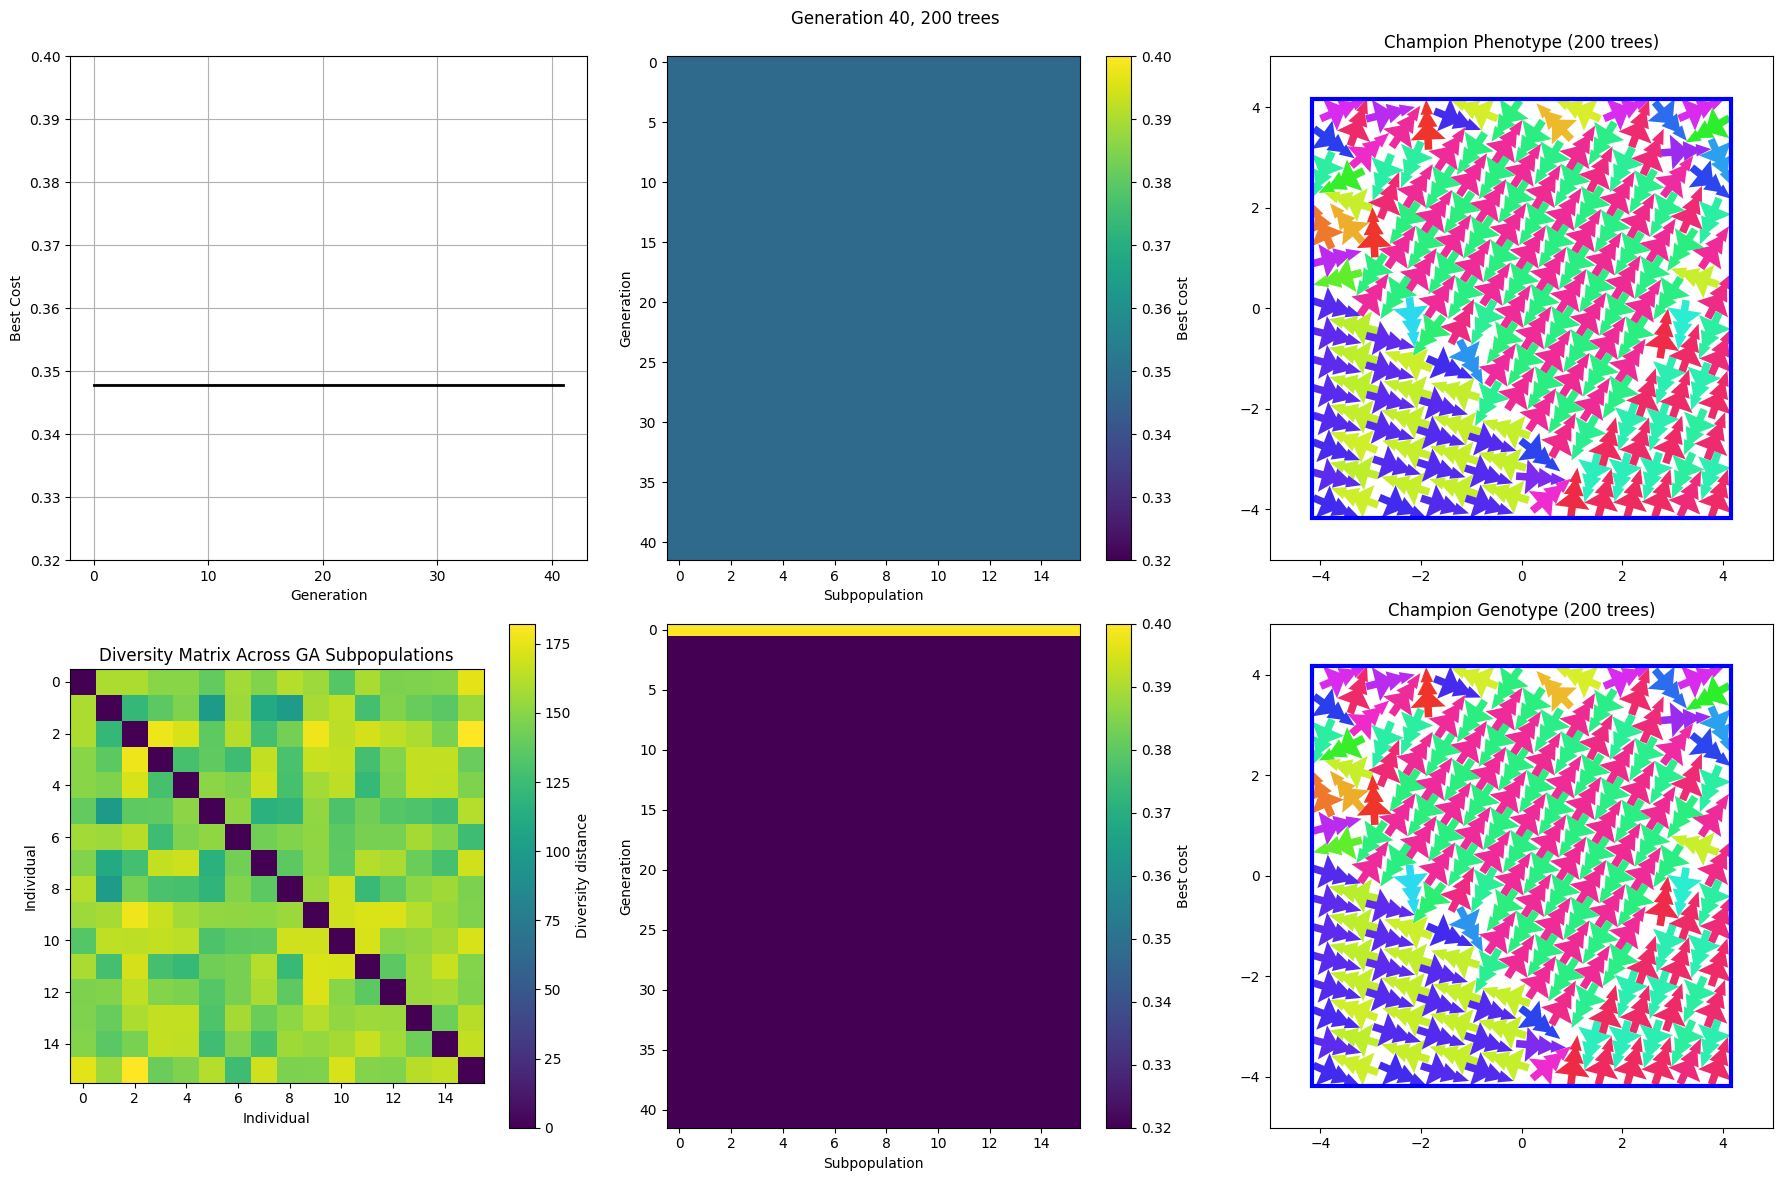

In [ ]:
runner = solve(200)

In [ ]:
# After solve() returns a runner with a better score:
champ = runner.ga.champions[0].phenotype

# 1. Read current submission
df_sub = pd.read_csv(kgs.submission_csv_path)
best_solutions, _ = pack_io.dataframe_to_solution_list(df_sub)

# 2. Replace the specific puzzle (0-indexed)
idx = num_trees - 1  # e.g. 49 for 50 trees
best_solutions[idx] = champ

# 3. Write back
df_new = pack_io.solution_list_to_dataframe(best_solutions)
df_new.to_csv('submission.csv', index=False)